<a href="https://colab.research.google.com/github/sbaratam-alt/fds-roshini/blob/main/Measures_of_dispersion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare  
0      0         A/5 21171   7.2500  
1      0          PC 17599  71.2833  
2      0  STON/O2. 3101282   7.9250  
3      0            113803  53.1000  
4      0            373450   8.0500  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entr

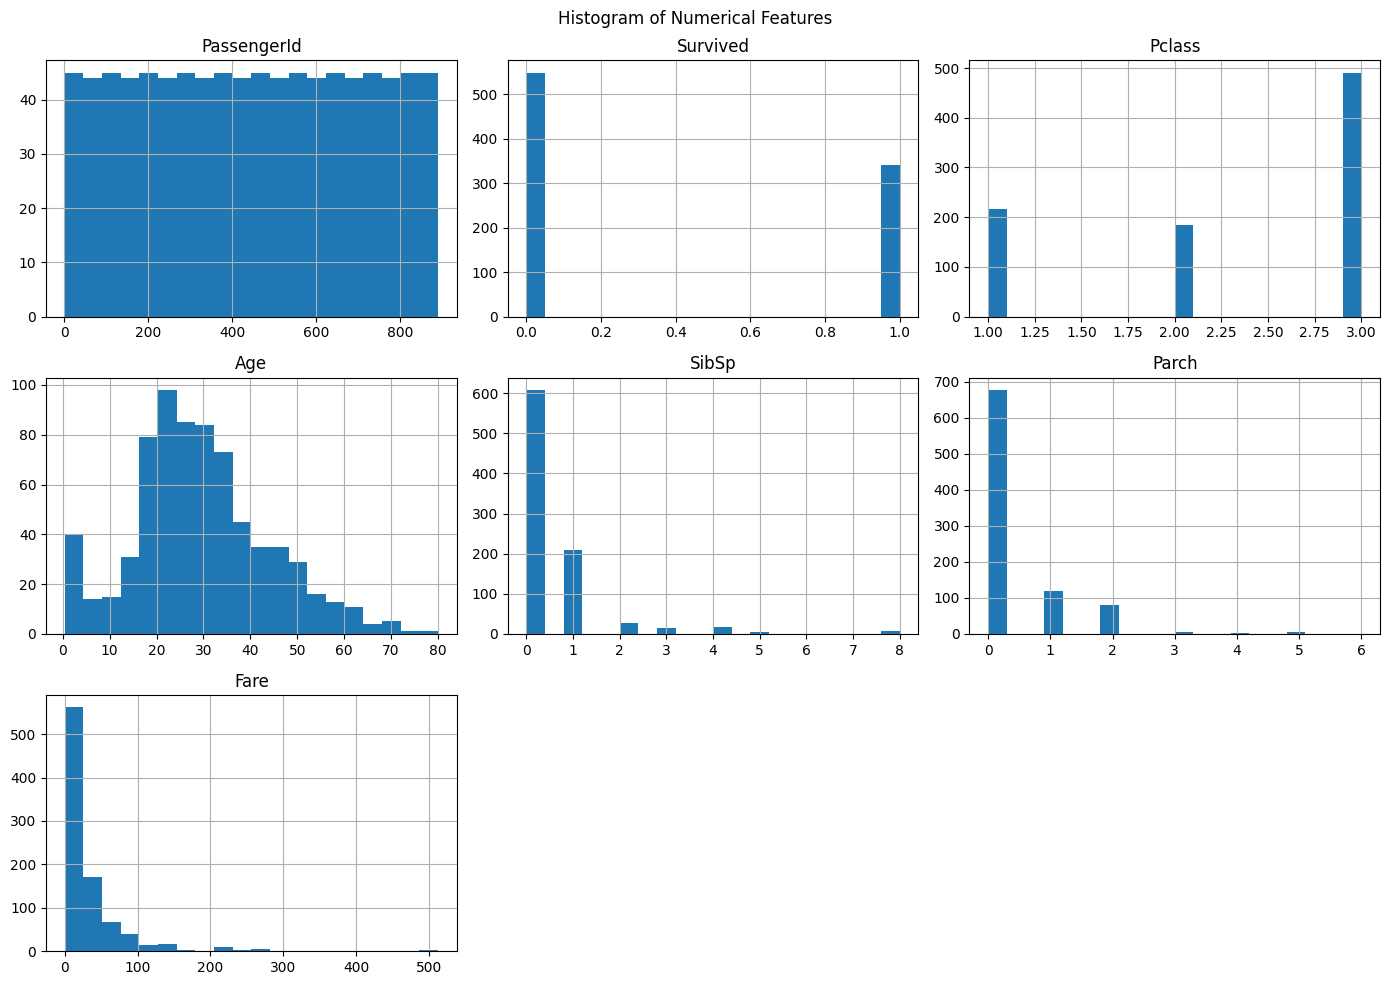

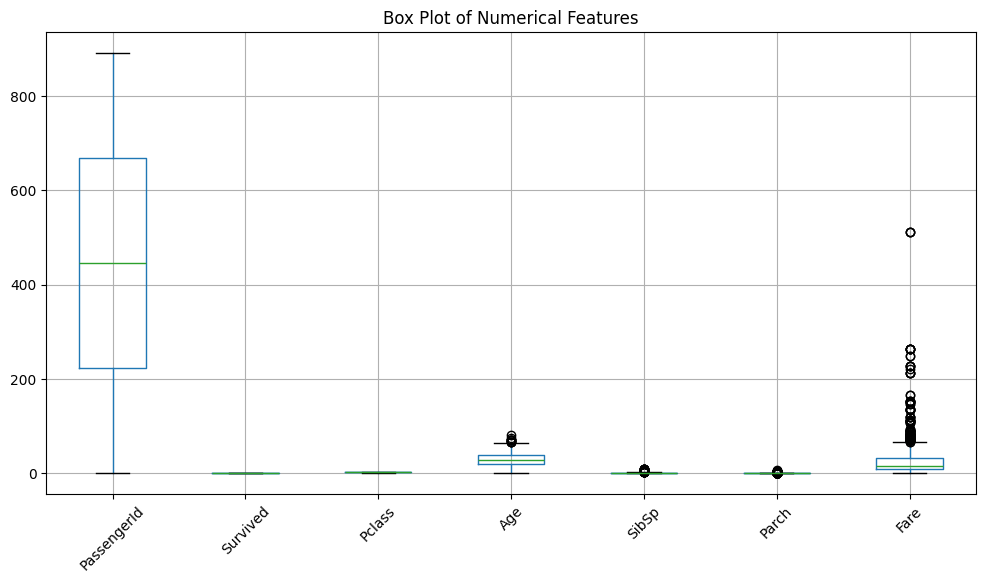

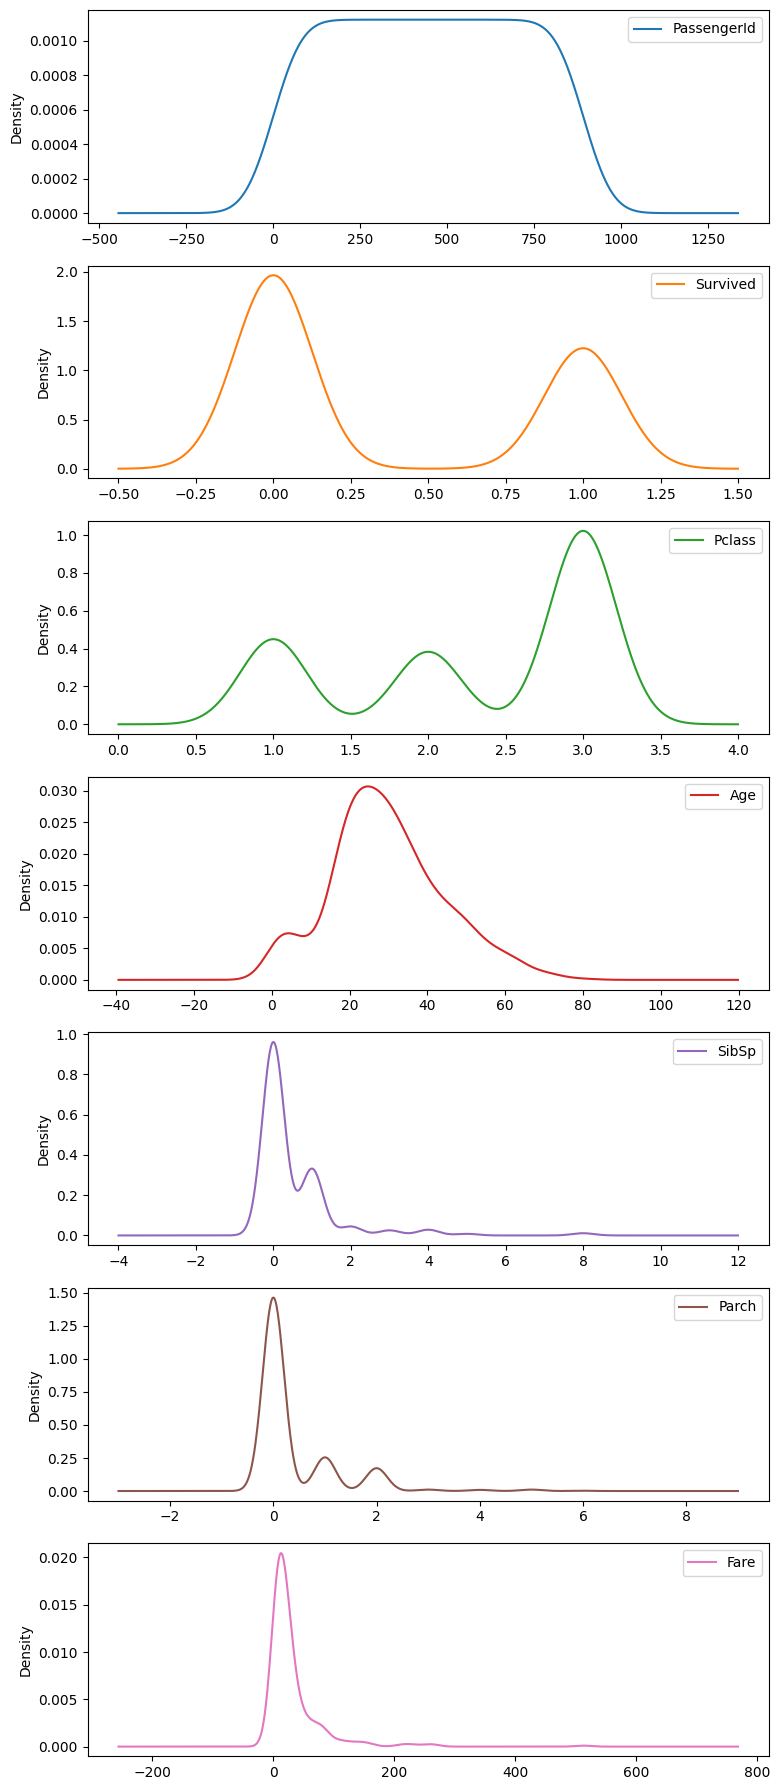

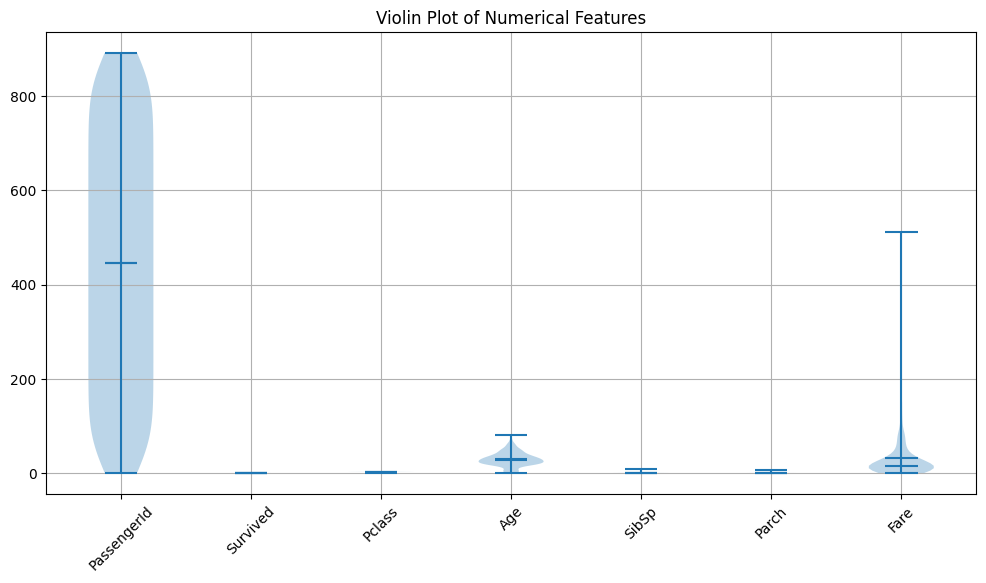


Summary Statistics
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [1]:
# ============================================
# TITANIC DATASET - MEASURES OF DISPERSION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read Dataset
df = pd.read_csv("Titanic-Dataset-selected-columns.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

# Select Numerical Columns
numeric_cols = df.select_dtypes(include=np.number).columns

print("\nNumerical Columns:")
print(numeric_cols)

# ============================================
# Measures of Dispersion
# ============================================

dispersion = pd.DataFrame(index=numeric_cols)

dispersion["Range"] = df[numeric_cols].max() - df[numeric_cols].min()
dispersion["Variance"] = df[numeric_cols].var()
dispersion["Standard Deviation"] = df[numeric_cols].std()
dispersion["Interquartile Range (IQR)"] = (
    df[numeric_cols].quantile(0.75) -
    df[numeric_cols].quantile(0.25)
)

dispersion["Minimum"] = df[numeric_cols].min()
dispersion["Maximum"] = df[numeric_cols].max()

print("\nMeasures of Dispersion")
print(dispersion)

# ============================================
# Histogram
# ============================================

df[numeric_cols].hist(figsize=(14,10), bins=20)

plt.suptitle("Histogram of Numerical Features")
plt.tight_layout()
plt.show()

# ============================================
# Box Plot
# ============================================

plt.figure(figsize=(12,6))
df[numeric_cols].boxplot()

plt.title("Box Plot of Numerical Features")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# ============================================
# Density Plot
# ============================================

df[numeric_cols].plot(kind='density',
                      subplots=True,
                      layout=(len(numeric_cols),1),
                      figsize=(8,18),
                      sharex=False)

plt.tight_layout()
plt.show()

# ============================================
# Violin Plot (using matplotlib only)
# ============================================

plt.figure(figsize=(12,6))

plt.violinplot(
    [df[col].dropna() for col in numeric_cols],
    showmeans=True,
    showmedians=True
)

plt.xticks(range(1, len(numeric_cols)+1), numeric_cols, rotation=45)

plt.title("Violin Plot of Numerical Features")
plt.grid(True)
plt.show()

# ============================================
# Summary
# ============================================

print("\nSummary Statistics")
print(df[numeric_cols].describe())